In [1]:
%load_ext autoreload
%autoreload 2

# Prova con 400 epoche e training set con 5000 x 3 dati: ottimo risultato sulla funzione semplice

Todo: provare con funzione coi seni, magari espandendo la targetnetwork

In [2]:
import os

# CPU fallback (if GPU is not available)
if 'JAX_PLATFORMS' not in os.environ:
    try:
        from jax import devices
        if not any(d.platform == 'gpu' for d in devices()):
            os.environ['JAX_PLATFORMS'] = 'cpu'
    except Exception:
        os.environ['JAX_PLATFORMS'] = 'cpu'

# Import necessary libraries
import jax.numpy as jnp
import jax.random as random
import optax
from data import Dataset, JaxDataLoader
from models import MLP
from training import assign_parameters, EarlyStopping
from utils import variables_generator
from losses import CustomLoss, RRMSE, MAE, l2_loss
from flax import nnx
import optax
import matplotlib.pyplot as plt
from training import train_and_evaluate

In [3]:
f_to_learn = lambda mu, l, k, x: jnp.exp(l*x) + 0*mu*x + k*x**2

# DATASET GENERATION
key = random.key(0)
mu_domain = (-2, 2)
l_domain = (0, 1)
k_domain = (-2, 2)
x_domain = (-1, 1)
N = 10000
n_realizations = 10
mu, l, k, x = variables_generator(N=N, n_realizations=n_realizations, var_names=['x'], var_domains=[x_domain], hypervar_domains=[mu_domain, l_domain, k_domain], hypervar_names=['mu', 'l', 'k'], key=key).values()
y = f_to_learn(mu, l, k, x)
X = jnp.stack([mu, l, k, x], axis=1)

# DATASET SPLIT AND DATALOADERS CREATION
split_idx1, split_idx2 = int(N * 0.8), int(N * 0.9)
X_train, X_val, X_test = X[:split_idx1], X[split_idx1:split_idx2], X[split_idx2:]
y_train, y_val, y_test = y[:split_idx1], y[split_idx1:split_idx2], y[split_idx2:]

# Create datasets and dataloaders
batch_size = 1024
dataset_train = Dataset(vars=X_train[:, 3], hypervars=X_train[:, :3], labels=y_train)
dataset_val = Dataset(vars=X_val[:, 3], hypervars=X_val[:, :3], labels=y_val)
dataset_test = Dataset(vars=X_test[:, 3], hypervars=X_test[:, :3], labels=y_test)

train_dataloader = JaxDataLoader(dataset_train, batch_size=batch_size, shuffle=True)
val_dataloader = JaxDataLoader(dataset_val, batch_size=batch_size, shuffle=False)
test_dataloader = JaxDataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [4]:
# Model definition
targetnetwork = MLP(input_dim=1, output_dim=1, hidden_dims=[8, 8], num_hidden_layers=2, rngs=nnx.Rngs(0), activation_functions=[nnx.tanh, nnx.tanh])
num_params = targetnetwork.num_parameters
hypernetwork = MLP(input_dim=3, output_dim=num_params, hidden_dims=[32, 32, 128], num_hidden_layers=3, rngs=nnx.Rngs(0), activation_functions=[nnx.relu, nnx.relu, nnx.relu])

# Loss, metrics and epochs
criterion = l2_loss #criterion = CustomLoss(l2_penalty_weight=1e-4)
metrics = [RRMSE, MAE]
epochs = 10000

# Epochs, scheduler, optimizer and early stopping
early_stopping = EarlyStopping(patience=300, min_delta=1e-6)
lr_schedule = optax.schedules.cosine_decay_schedule(init_value=1e-2, decay_steps=epochs, alpha=1e-6) #SE USIAMO QUESTO METTERAI DECAY LENTO, IO PROVEREI ALTRI SCHEDULER
schedule_optimizer = nnx.Optimizer(hypernetwork, optax.adam(learning_rate=lr_schedule))

plateau_scheduler = optax.contrib.reduce_on_plateau(factor=0.5, patience=10)
plateau_optimizer = optax.chain(
    optax.adam(learning_rate=1e-2),
    plateau_scheduler
) # NON SI PUO JITTARE

# Training
log_file_path = "training_log.txt"
history = train_and_evaluate(
        hypernetwork=hypernetwork,
        targetnetwork=targetnetwork,
        train_loader=train_dataloader,
        val_loader=val_dataloader,
        optimizer=schedule_optimizer,
        num_epochs=epochs,
        criterion=criterion,
        metrics=metrics,
        early_stopping_metric='RRMSE',
        early_stopping=early_stopping,
        log_file_path=log_file_path
)

Epoch 1515/10000 - Train: loss: 0.0000, RRMSE: 0.0026, MAE: 0.0024 - Val: loss: 0.0000, RRMSE: 0.0068, MAE: 0.0052:  15%|█▌        | 1514/10000 [01:04<06:01, 23.47it/s]

Early stopping at epoch 1515. Best epoch was 1215 with loss 0.00675636.


In [6]:
# TODO: HO DIVISO IN TRAIN, VAL E TEST, QUINDI BISOGNA FARE UNA FUNZIONE CHE TESTA SUL TEST SET

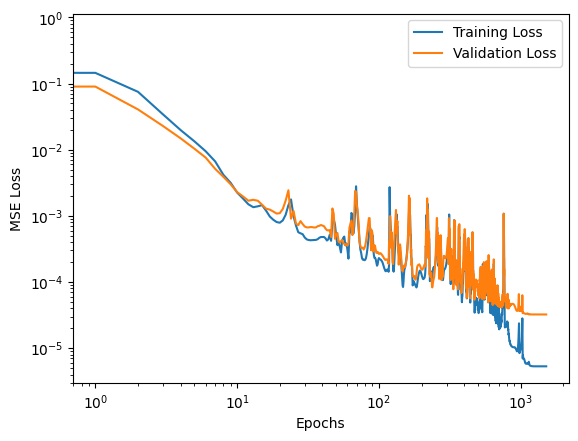

In [7]:
training_loss_history = [m['loss'] for m in history['train_metrics']]
val_loss_history = [m['loss'] for m in history['val_metrics']]
plt.loglog(range(len(training_loss_history)), training_loss_history, label='Training Loss')
plt.loglog(range(len(val_loss_history)), val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [7]:
# PLOTTING RESULTS ON SOME EXAMPLES
N_example = 4
key_example = random.key(1)  # DON'T PUT 0 TO AVOID DATA LEAKAGE
mu_example, l_example, k_example = variables_generator(N = N_example, var_domains = [mu_domain, l_domain, k_domain], key = key_example).values()

example_hypervars = jnp.stack([mu_example, l_example, k_example], axis=1)
particular_hypervars= jnp.array([[0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
example_hypervars = jnp.vstack([example_hypervars, particular_hypervars]) 

x_vector = jnp.linspace(-1, 1, 101)
x_vector = x_vector[:,None]

In [8]:
plots_data = []

for hypervars in example_hypervars:
    w = hypernetwork(hypervars)  # get the weights from the hypernetwork
    targetnetwork = assign_parameters(targetnetwork, w)  # assign the weights to the target network
    mu, l, k = hypervars 
    y_pred = targetnetwork(x_vector)  # predicted function values
    y_vector = jnp.array([f_to_learn(mu, l, k, x) for x in x_vector])  # true function values
    
    plots_data.append({ #store data for plotting
        'x': x_vector,
        'y_pred': y_pred,
        'y_true': y_vector,
        'params': (mu, l, k)
    })

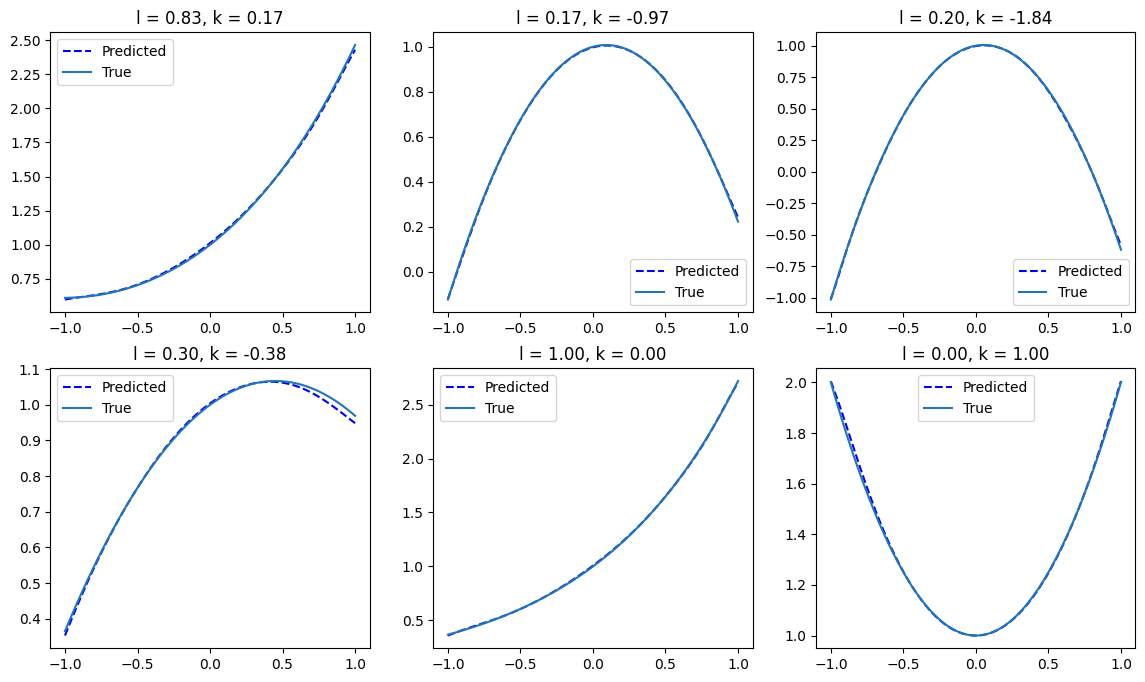

In [9]:
num_cols = 3
fig, ax = plt.subplots(2,num_cols, figsize=(14, 8))
for i, data in enumerate(plots_data[0:6]):
    ax[i//num_cols, i%num_cols].plot(data['x'], data['y_pred'], '--b')
    ax[i//num_cols, i%num_cols].plot(data['x'], data['y_true'])
    ax[i//num_cols, i%num_cols].legend(['Predicted', 'True'])
    ax[i//num_cols, i%num_cols].set_title(f'l = {data["params"][1]:.2f}, k = {data["params"][2]:.2f}')
plt.show()